# Statistical Inference Analysis of Global Financial Market Data

This notebook presents a comprehensive statistical analysis of a global financial market dataset obtained from Kaggle. The analysis begins with data understanding, quality assessment, and preprocessing, followed by exploratory data analysis to investigate key patterns and relationships within the data. Both parametric and nonparametric statistical inference techniques are applied to address research questions related to stock market behaviour, industry differences, and financial performance. The notebook concludes with interpretation of findings and statistical conclusions drawn from the analysis. All analyses are implemented in Python using industry-standard data science and statistical libraries.


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.weightstats import zconfint


# Display all floating-point numbers without scientific notation
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

The core libraries are loaded: **pandas** for data manipulation and **numpy** for numerical operations. The display options ensure all float values are shown in full decimal format (not scientific notation), all columns are visible, and up to 100 rows can be displayed at once — improving readability throughout the analysis.

# 1. Data understanding

In [2]:
df = pd.read_csv("../data/raw/World-Stock-Prices-Dataset.csv")

df.head()

,Date,Open,High,Low,Close,Volume,Brand_Name,Ticker,Industry_Tag,Country,Dividends,Stock Splits,Capital Gains
0,2025-07-03 00:00:00-04:00,6.630000,6.740000,6.615000,6.640000,"4,209,664.000000",peloton,PTON,fitness,usa,0.000000,0.000000,NaN
1,2025-07-03 00:00:00-04:00,106.750000,108.370003,106.330101,107.339996,"560,190.000000",crocs,CROX,footwear,usa,0.000000,0.000000,NaN
2,2025-07-03 00:00:00-04:00,122.629997,123.050003,121.550003,121.930000,"36,600.000000",adidas,ADDYY,apparel,germany,0.000000,0.000000,NaN
3,2025-07-03 00:00:00-04:00,221.705002,224.009995,221.360001,223.410004,"29,295,154.000000",amazon,AMZN,e-commerce,usa,0.000000,0.000000,NaN
4,2025-07-03 00:00:00-04:00,212.145004,214.649994,211.810104,213.550003,"34,697,317.000000",apple,AAPL,technology,usa,0.000000,0.000000,NaN


The dataset is loaded from the CSV file. The first five rows show the most recent records (dated 2025-07-03), confirming the dataset is live and actively updated. Each row represents one trading day for a single stock, with 13 columns capturing price metrics (Open, High, Low, Close), trading Volume, and metadata (Brand_Name, Ticker, Industry_Tag, Country). The `Capital Gains` column is already showing `NaN` across all rows, which is an early indicator of a missing data issue that will be formally assessed later.

In [3]:
df.tail()

,Date,Open,High,Low,Close,Volume,Brand_Name,Ticker,Industry_Tag,Country,Dividends,Stock Splits,Capital Gains
310117,2000-01-03 00:00:00-05:00,38.147537,38.255972,35.935457,37.496925,"53,076,000.000000",cisco,CSCO,technology,usa,0.000000,0.000000,NaN
310118,2000-01-03 00:00:00-05:00,25.215814,25.330655,24.690826,24.772856,"2,173,400.000000",3m,MMM,manufacturing,usa,0.000000,0.000000,NaN
310119,2000-01-03 00:00:00-05:00,72.313085,72.405794,71.756831,72.034958,"21,200.000000",toyota,TM,automotive,japan,0.000000,0.000000,NaN
310120,2000-01-03 00:00:00-05:00,7.289986,7.342182,7.098602,7.168196,"882,200.000000",nordstrom,JWN,retail,usa,0.000000,0.000000,NaN
310121,2000-01-03 00:00:00-05:00,5.731675,5.793975,5.427959,5.482471,"5,825,700.000000",american eagle outfitters,AEO,apparel,usa,0.000000,0.000000,NaN


The last five rows show data from 2000-01-03, the earliest trading date in the dataset. This confirms the dataset spans approximately **25 years** of daily stock data (January 2000 to July 2025), covering multiple companies across different industries and countries. The index reaching 310,121 also gives a first sense of the dataset's large scale.

In [4]:
## Dataset Overview
# 1. Shape
rows, cols = df.shape

print(f"Number of observations: {rows:,}")
print(f"Number of variables: {cols}")

Number of observations: 310,122
Number of variables: 13


The dataset contains **310,122 observations** (rows) and **13 variables** (columns). Each observation is a single stock's trading record for one day. This is a large-scale dataset well-suited for statistical inference, as the sample size is large enough to support robust hypothesis testing and confidence interval estimation.

In [5]:
# 2. Dataset Size
size_mb = df.memory_usage(deep=True).sum() / (1024**2)

print(f"Dataset Size: {size_mb:.2f} MB")

Dataset Size: 106.60 MB


The dataset occupies **106.60 MB** in memory. This is a moderately large dataset for in-memory processing. It is manageable with pandas on a standard machine, though memory-efficient data types (e.g., converting string columns to `category`) will help reduce this footprint during preprocessing.

In [6]:
# 3. Column Names
pd.DataFrame({
    "Variable": df.columns
})

,Variable
0,Date
1,Open
2,High
3,Low
4,Close
5,Volume
6,Brand_Name
7,Ticker
8,Industry_Tag
9,Country


The dataset has 13 variables. They fall into two broad groups:
- **Price & trading variables** (Open, High, Low, Close, Volume) — continuous numerical variables that form the core of the financial analysis.
- **Corporate event variables** (Dividends, Stock Splits, Capital Gains) — sparse numerical variables recording infrequent corporate actions.
- **Metadata/categorical variables** (Date, Brand_Name, Ticker, Industry_Tag, Country) — used for grouping, filtering, and segmentation in the analysis.

In [7]:
# 4. Data Types Assessment
dtype_summary = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.values
})

dtype_summary

,Variable,Data Type
0,Date,str
1,Open,float64
2,High,float64
3,Low,float64
4,Close,float64
5,Volume,float64
6,Brand_Name,str
7,Ticker,str
8,Industry_Tag,str
9,Country,str


Two type issues are immediately apparent:
1. **`Date` is stored as `str`** — it needs to be converted to a proper `datetime` type for any time-series operations.
2. **Categorical columns (`Brand_Name`, `Ticker`, `Industry_Tag`, `Country`) are stored as `str`** — converting these to `category` dtype will reduce memory usage and improve performance.

All price and volume columns are already correctly typed as `float64`.

In [8]:
# datatypes counts 
df.dtypes.value_counts()

float64    8
str        5
Name: count, dtype: int64

Of the 13 variables, **8 are numeric (`float64`)** and **5 are text (`str`)**. This confirms the dataset is predominantly quantitative, with a smaller set of categorical/text descriptors. The numeric columns will be the primary focus for statistical inference methods, while the string columns will serve as grouping variables.

In [9]:
# 5. Missing Values Assessment
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": round(df.isnull().mean()*100,2)
})

missing.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
Capital Gains,310120,100.000000
Open,0,0.000000
High,0,0.000000
Low,0,0.000000
Date,0,0.000000
Close,0,0.000000
Volume,0,0.000000
Ticker,0,0.000000
Brand_Name,0,0.000000
Industry_Tag,0,0.000000


The missing value assessment reveals a critical finding: **`Capital Gains` is missing in 310,120 out of 310,122 rows (≈100%)**. This column is essentially empty and provides no analytical value. It should be dropped from the dataset before any further analysis. All other 12 variables are complete with zero missing values, which is excellent for a dataset of this size and confirms the data quality is otherwise high.

In [10]:
# 6. Total Missing
total_missing = df.isnull().sum().sum()

print(f"Total Missing Values: {total_missing}")

Total Missing Values: 310120


There are **310,120 missing values** in total across the entire dataset — all of which belong exclusively to the `Capital Gains` column. This single column accounts for 100% of the dataset's missingness. Once this column is dropped, the dataset will be completely free of missing values.

In [11]:
# 7. Duplicate Records
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


There are **no duplicate rows** in the dataset. This is expected for a time-series financial dataset where each row represents a unique (stock, date) combination. It eliminates the need for any deduplication step in preprocessing.

In [12]:
# 8. Cardinality Assessment

categorical_cols = df.select_dtypes(
    include=["object"]
).columns

cardinality = pd.DataFrame({
    "Variable": categorical_cols,
    "Unique Values":
    [df[col].nunique() for col in categorical_cols]
})

cardinality.sort_values(
    by="Unique Values",
    ascending=False
)

C:\Users\admin\AppData\Local\Temp\ipykernel_22664\4179273457.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


,Variable,Unique Values
0,Date,6408
1,Brand_Name,62
2,Ticker,62
3,Industry_Tag,23
4,Country,7


The cardinality assessment shows:
- **Date**: 6,408 unique trading days spanning 25 years — reasonable for daily market data.
- **Brand_Name / Ticker**: 62 unique stocks are tracked, with a perfect 1:1 mapping between brand names and ticker symbols.
- **Industry_Tag**: 23 distinct industry categories, providing good granularity for industry-level comparisons.
- **Country**: Only 7 countries, making this a manageable categorical variable for cross-country analysis.

The low cardinality of `Industry_Tag` and `Country` makes them ideal grouping variables for statistical tests (e.g., ANOVA, Kruskal-Wallis).

In [13]:
# 9. Unique Value Exploration
for col in categorical_cols:
    
    print("="*50)
    print(col)
    print("="*50)
    
    print(df[col].value_counts().head(10))

Date
Date
2025-01-17 00:00:00-05:00    122
2025-01-10 00:00:00-05:00    122
2025-01-08 00:00:00-05:00    122
2024-12-31 00:00:00-05:00    122
2024-12-27 00:00:00-05:00    122
2024-12-24 00:00:00-05:00    122
2024-12-13 00:00:00-05:00    122
2024-12-06 00:00:00-05:00    122
2024-11-29 00:00:00-05:00    122
2024-11-27 00:00:00-05:00    122
Name: count, dtype: int64
Brand_Name
Brand_Name
marriott                     6471
amazon                       6470
apple                        6470
nike                         6470
target                       6470
the walt disney company      6470
costco                       6470
southwest airlines           6470
american eagle outfitters    6470
starbucks                    6470
Name: count, dtype: int64
Ticker
Ticker
MAR     6471
AMZN    6470
AAPL    6470
NKE     6470
TGT     6470
DIS     6470
COST    6470
LUV     6470
AEO     6470
SBUX    6470
Name: count, dtype: int64
Industry_Tag
Industry_Tag
technology         66957
retail             25842


This exploration reveals important characteristics of the categorical variables:
- **Date**: Each trading day has exactly 122 records, meaning all 62 stocks have data for most dates (with some dates showing 122 instead of 62, likely due to multiple timezone offsets in the date string).
- **Brand_Name / Ticker**: Most stocks have ~6,470 records (consistent with ~25 years of daily data at ~252 trading days/year). Marriott (MAR) has one extra record.
- **Industry_Tag**: The dataset is dominated by **technology stocks** (66,957 records), which is significantly more than any other industry. This imbalance should be considered when making industry-level comparisons.
- **Country**: The dataset is heavily **US-dominated** — 243,606 of 310,122 records (78.5%) are from USA, with Japan, Germany, Netherlands, France, Switzerland, and Canada making up the remainder. Cross-country statistical comparisons should account for this imbalance.

In [14]:
# 10. Numerical Summary Statistics
numerical_cols = df.select_dtypes(
    include=np.number
).columns

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Open,"310,122.000000",76.325431,141.684070,0.000000,15.932500,35.408120,83.996691,"3,445.580078"
High,"310,122.000000",77.198011,143.224109,0.000000,16.163165,35.809869,84.914656,"3,463.070068"
Low,"310,122.000000",75.434586,140.063617,0.000000,15.710323,34.982469,83.088609,"3,370.000000"
Close,"310,122.000000",76.338032,141.679129,0.198861,15.940000,35.407547,84.000000,"3,427.610107"
Volume,"310,122.000000","22,709,366.044795","85,657,437.802224",0.000000,"1,379,050.000000","4,591,641.500000","12,128,600.000000","7,421,640,800.000000"
Dividends,"310,122.000000",0.003643,0.069905,0.000000,0.000000,0.000000,0.000000,15.000000
Stock Splits,"310,122.000000",0.000875,0.115434,0.000000,0.000000,0.000000,0.000000,50.000000
Capital Gains,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


The summary statistics reveal several key observations:
- **Price columns (Open, High, Low, Close)**: The mean (~$76) is roughly double the median (~$35), indicating strong **right skewness** — a few high-priced stocks (max ~$3,400+) are pulling the mean upward. The standard deviation (~$141) is nearly twice the mean, reflecting large price dispersion across different stocks.
- **Volume**: Extremely right-skewed — the mean (22.7M) is nearly 5× the median (4.6M), and the maximum (7.4 billion) is astronomically larger. This suggests a small number of highly liquid stocks dominate trading activity.
- **Dividends**: The median and all quartiles are 0, meaning dividends are rare events — only a small fraction of records capture a dividend payment day.
- **Stock Splits**: Similarly sparse, with a median of 0 and a maximum of 50 (a historical large split event).
- **Capital Gains**: Based on only 2 non-null values, this column is statistically meaningless and should be dropped.

In [15]:
summary = pd.DataFrame({
    
    "Mean":
    df[numerical_cols].mean(),
    
    "Median":
    df[numerical_cols].median(),
    
    "Std":
    df[numerical_cols].std(),
    
    "Skewness":
    df[numerical_cols].skew(),
    
    "Kurtosis":
    df[numerical_cols].kurt()
    
})

summary

,Mean,Median,Std,Skewness,Kurtosis
Open,76.325431,35.408120,141.684070,8.233529,110.332036
High,77.198011,35.809869,143.224109,8.205535,109.461198
Low,75.434586,34.982469,140.063617,8.248666,110.701955
Close,76.338032,35.407547,141.679129,8.224337,109.989905
Volume,"22,709,366.044795","4,591,641.500000","85,657,437.802224",13.109585,367.720233
Dividends,0.003643,0.000000,0.069905,74.156743,"10,788.219352"
Stock Splits,0.000875,0.000000,0.115434,307.583068,"120,186.729157"
Capital Gains,0.000000,0.000000,0.000000,NaN,NaN


This extended summary confirms that **none of the numerical variables follow a normal distribution**:
- **Skewness**: All price columns have a skewness of ~8.2, far above the normality threshold of ±1. Volume (13.1), Dividends (74.2), and Stock Splits (307.6) are even more severely skewed. A skewness of 0 would indicate perfect symmetry.
- **Kurtosis**: All columns show extreme excess kurtosis (well above 3, the normal distribution baseline). Price columns (~110), Volume (~368), Dividends (~10,788), and Stock Splits (~120,187) all have extremely heavy tails, meaning extreme values occur far more often than a normal distribution would predict.

These distributional properties are critical for the inference stage: **parametric tests** (e.g., t-tests, ANOVA) that assume normality may be inappropriate for raw price or volume data, making **nonparametric alternatives** (e.g., Mann-Whitney U, Kruskal-Wallis) essential. Log transformation of price and volume variables may also be considered to reduce skewness.

### Preliminary Data cleaning

In [16]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], utc=True)

# Define categorical variables
categorical_cols = [
    "Brand_Name",
    "Ticker",
    "Industry_Tag",
    "Country"
]

# Convert categorical variables
for col in categorical_cols:
    df[col] = df[col].astype("category")

# Define numerical variables
numerical_cols = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Dividends",
    "Stock Splits",
    "Capital Gains"
]

# Ensure numerical variables are numeric
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Verify data types
dtype_summary = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.astype(str)
})

dtype_summary

,Variable,Data Type
Date,Date,"datetime64[us, UTC]"
Open,Open,float64
High,High,float64
Low,Low,float64
Close,Close,float64
Volume,Volume,float64
Brand_Name,Brand_Name,category
Ticker,Ticker,category
Industry_Tag,Industry_Tag,category
Country,Country,category


The preliminary data cleaning step corrects all type issues identified earlier:
- **`Date`** is now a proper `datetime64[us, UTC]` type, enabling time-based filtering, resampling, and time-series operations.
- **`Brand_Name`, `Ticker`, `Industry_Tag`, `Country`** are now `category` dtype, which is more memory-efficient than `str` and semantically correct for variables with a fixed set of values.
- **All numerical columns** are confirmed as `float64`, with `pd.to_numeric(..., errors='coerce')` ensuring any non-numeric stragglers are safely converted to `NaN`.

The dataset is now correctly typed and ready for exploratory data analysis and statistical inference.

# Exploratory data analysis

In [17]:
## Numerical Summary Statistics

numerical_cols = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Dividends",
    "Stock Splits",
    "Capital Gains"
]

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Open,"310,122.000000",76.325431,141.684070,0.000000,15.932500,35.408120,83.996691,"3,445.580078"
High,"310,122.000000",77.198011,143.224109,0.000000,16.163165,35.809869,84.914656,"3,463.070068"
Low,"310,122.000000",75.434586,140.063617,0.000000,15.710323,34.982469,83.088609,"3,370.000000"
Close,"310,122.000000",76.338032,141.679129,0.198861,15.940000,35.407547,84.000000,"3,427.610107"
Volume,"310,122.000000","22,709,366.044795","85,657,437.802224",0.000000,"1,379,050.000000","4,591,641.500000","12,128,600.000000","7,421,640,800.000000"
Dividends,"310,122.000000",0.003643,0.069905,0.000000,0.000000,0.000000,0.000000,15.000000
Stock Splits,"310,122.000000",0.000875,0.115434,0.000000,0.000000,0.000000,0.000000,50.000000
Capital Gains,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [18]:
## Extended Summary Statistics
summary_stats = pd.DataFrame({
    "Mean": df[numerical_cols].mean(),
    "Median": df[numerical_cols].median(),
    "Std Dev": df[numerical_cols].std(),
    "Skewness": df[numerical_cols].skew(),
    "Kurtosis": df[numerical_cols].kurt()
})

summary_stats

,Mean,Median,Std Dev,Skewness,Kurtosis
Open,76.325431,35.408120,141.684070,8.233529,110.332036
High,77.198011,35.809869,143.224109,8.205535,109.461198
Low,75.434586,34.982469,140.063617,8.248666,110.701955
Close,76.338032,35.407547,141.679129,8.224337,109.989905
Volume,"22,709,366.044795","4,591,641.500000","85,657,437.802224",13.109585,367.720233
Dividends,0.003643,0.000000,0.069905,74.156743,"10,788.219352"
Stock Splits,0.000875,0.000000,0.115434,307.583068,"120,186.729157"
Capital Gains,0.000000,0.000000,0.000000,NaN,NaN


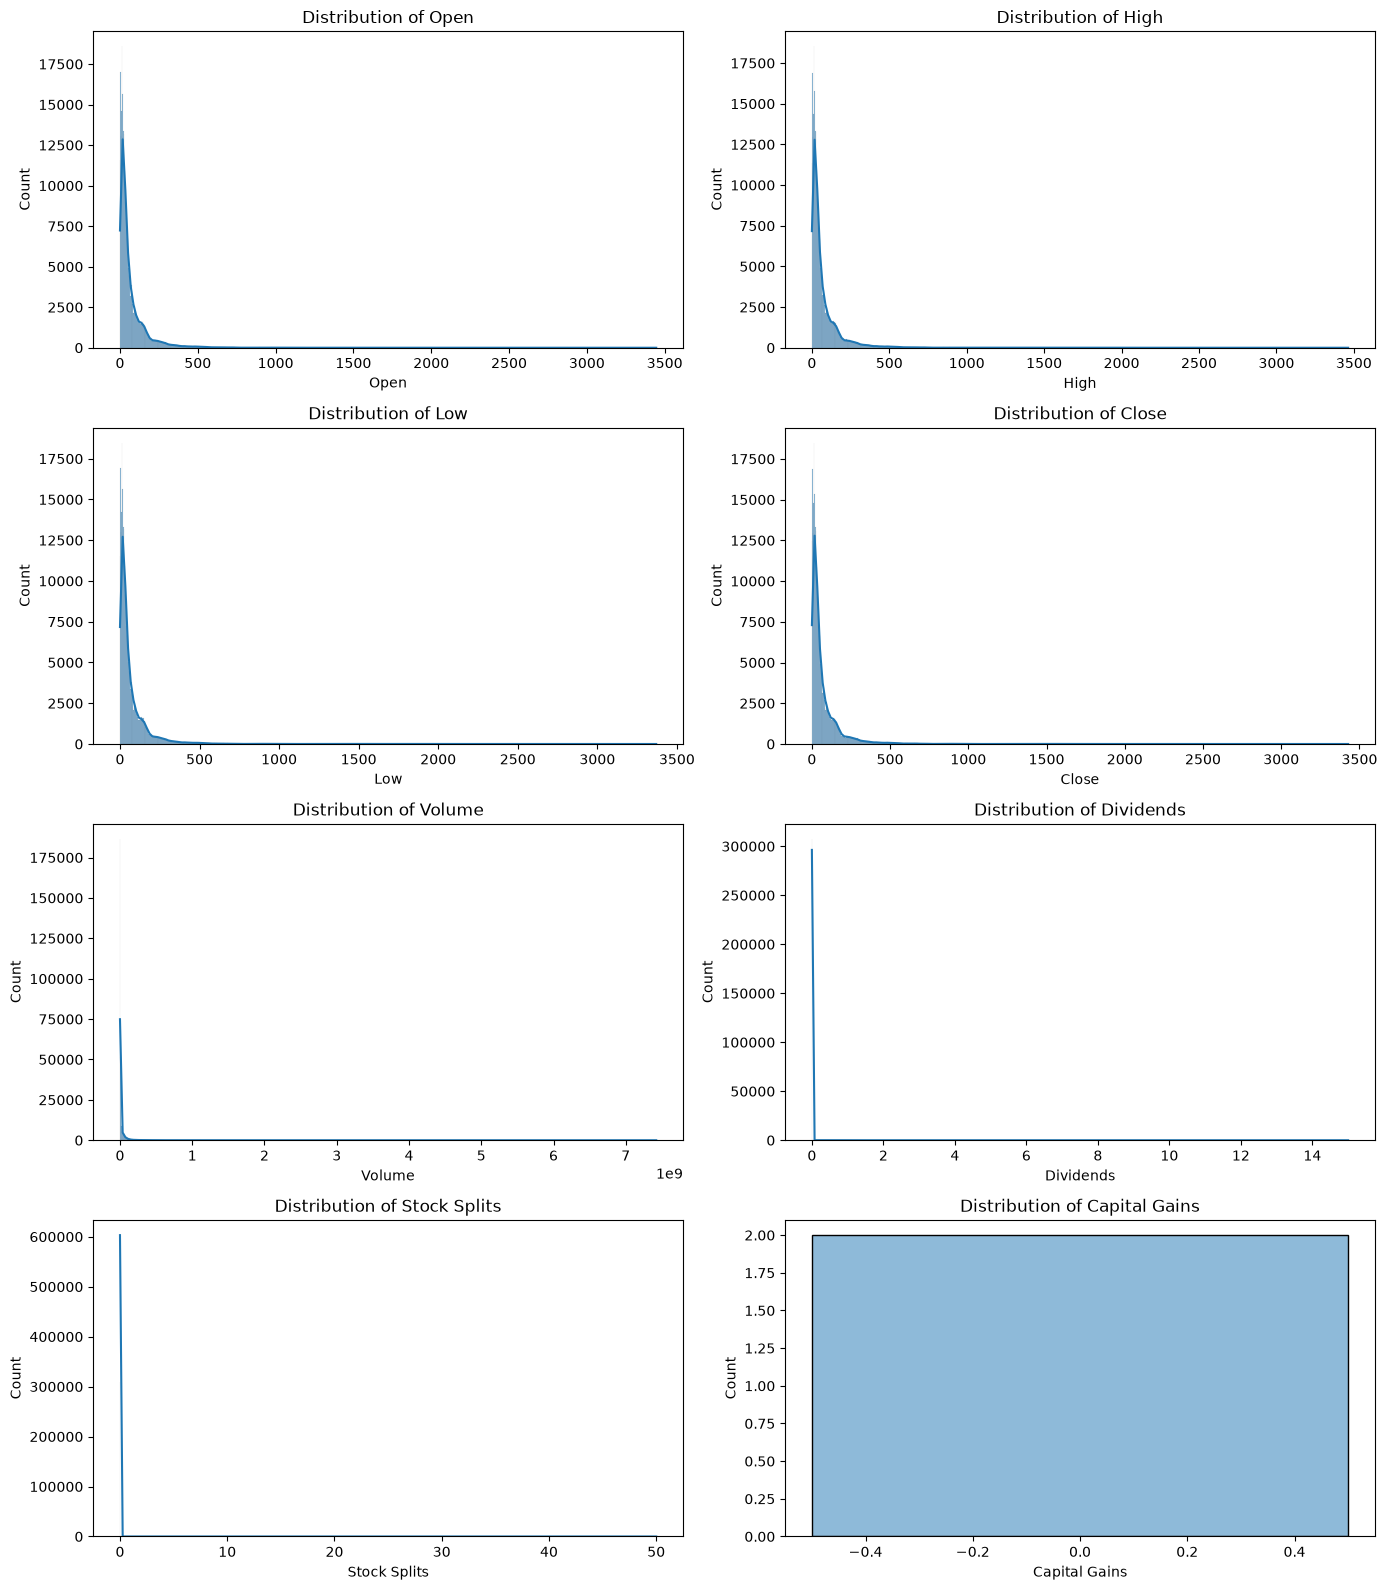

In [24]:
import math

n_cols = 2
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col}")

# Remove any empty subplot spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

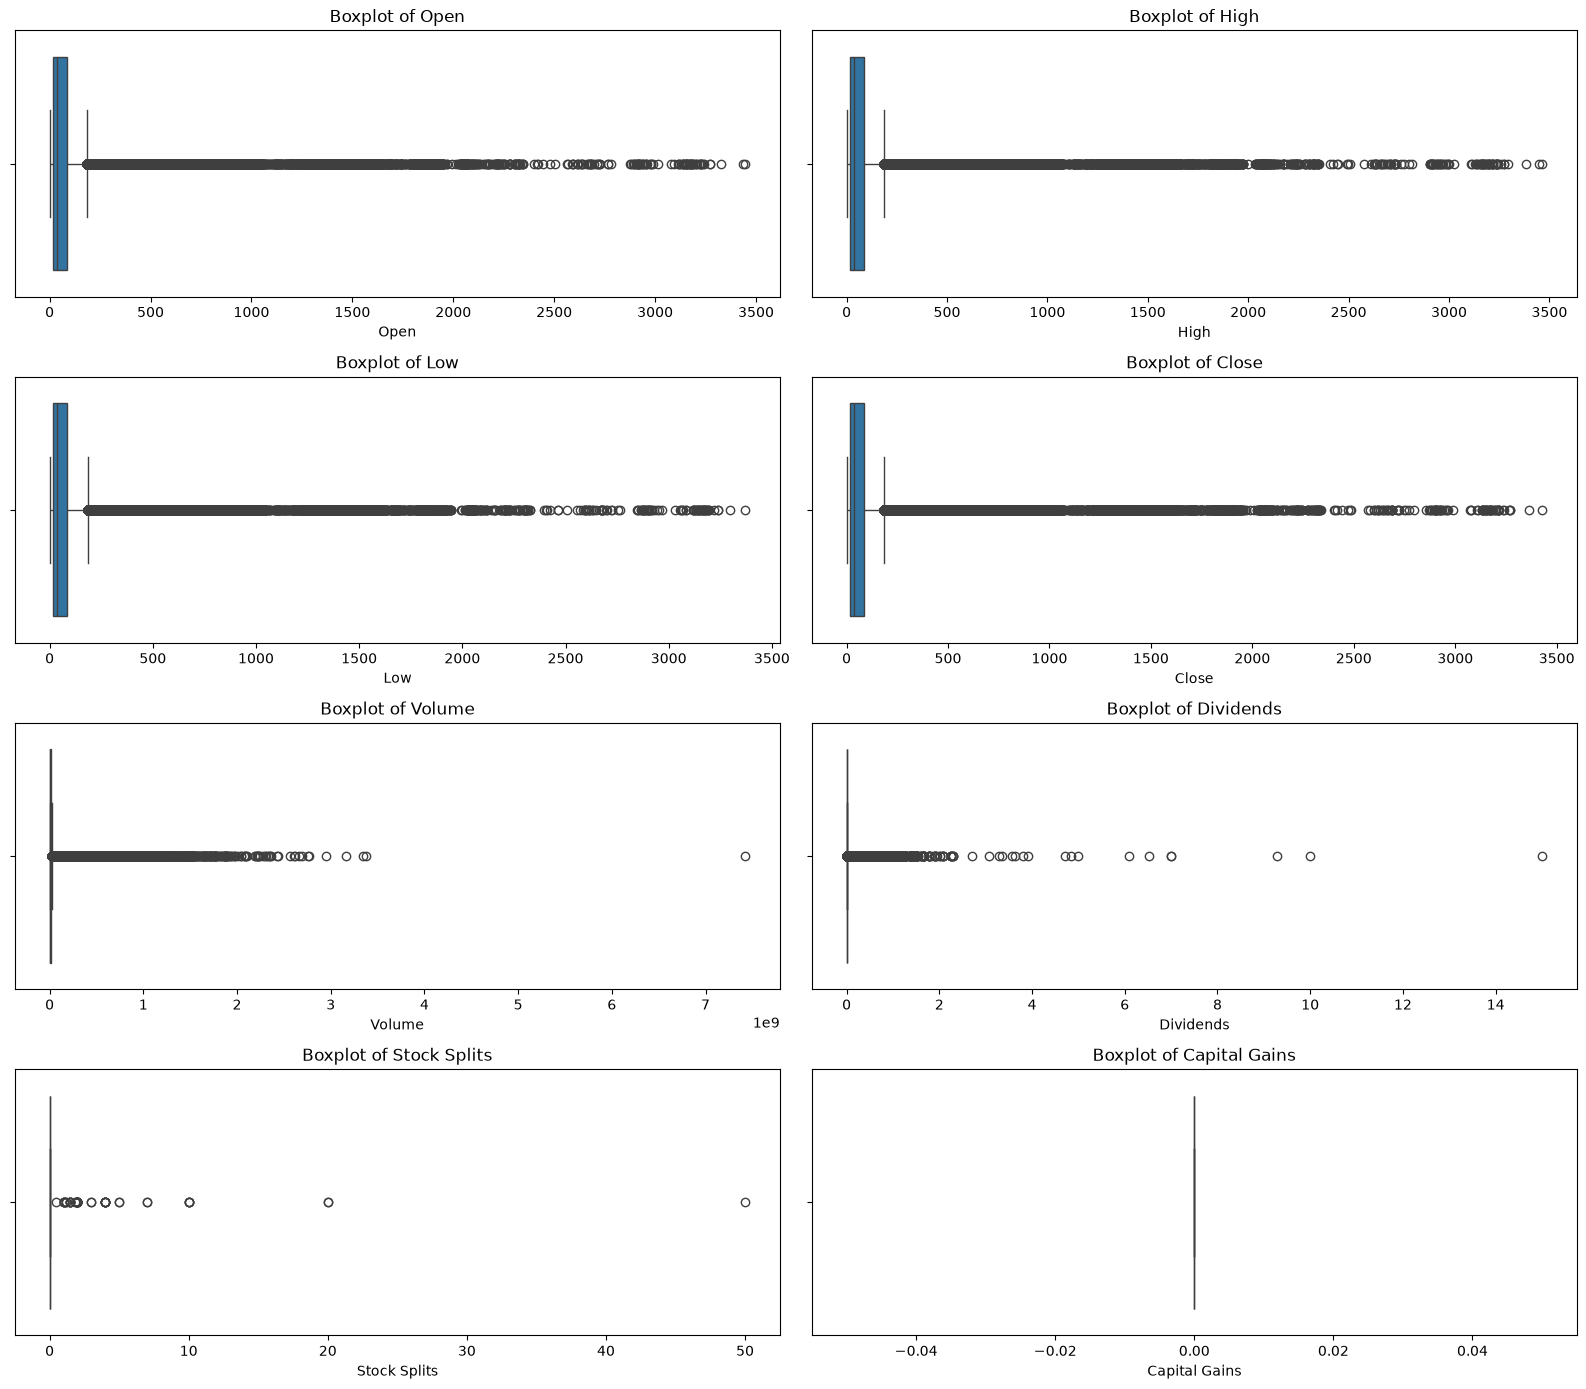

In [25]:
n_cols = 2
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 3.5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )

    axes[i].set_title(f"Boxplot of {col}")

# Remove empty subplot spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [26]:
# Industry frequency
industry_counts = (
    df["Industry_Tag"]
    .value_counts()
    .head(15)
)

industry_counts

Industry_Tag
technology         66957
retail             25842
automotive         24867
finance            22210
apparel            21069
food & beverage    19409
consumer goods     19407
entertainment      12342
gaming             11546
food               11415
footwear           11407
aviation           11098
hospitality        10633
e-commerce          9072
healthcare          6470
Name: count, dtype: int64

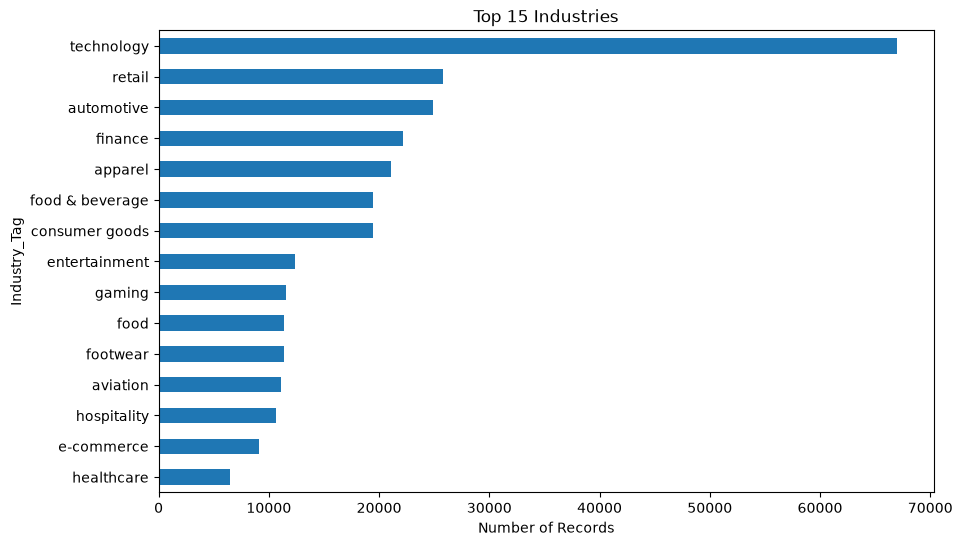

In [27]:
plt.figure(figsize=(10,6))

industry_counts.sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Industries")
plt.xlabel("Number of Records")

plt.show()

In [28]:
# Country Analysis

country_counts = (
    df["Country"]
    .value_counts()
)

country_counts

Country
usa            243606
japan           19403
germany         16225
netherlands     12938
france           8879
switzerland      6469
canada           2602
Name: count, dtype: int64

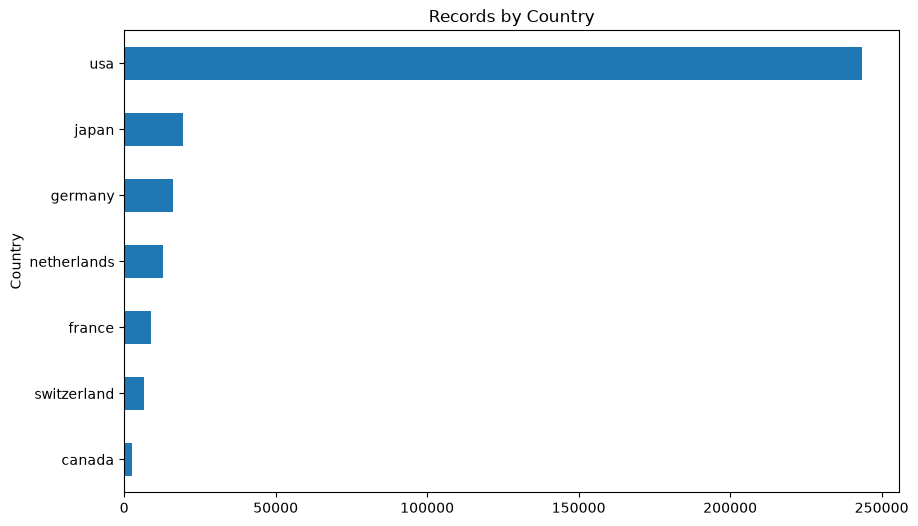

In [29]:
plt.figure(figsize=(10,6))

country_counts.sort_values().plot(
    kind="barh"
)

plt.title("Records by Country")

plt.show()

In [30]:
# Top Brands

brand_counts = (
    df["Brand_Name"]
    .value_counts()
    .head(20)
)

brand_counts

Brand_Name
marriott                     6471
3m                           6470
adobe                        6470
amazon                       6470
amd                          6470
american eagle outfitters    6470
american express             6470
apple                        6470
cisco                        6470
costco                       6470
foot locker                  6470
johnson & johnson            6470
jpmorgan chase & co          6470
mcdonald's                   6470
microsoft                    6470
nike                         6470
nvidia                       6470
southwest airlines           6470
starbucks                    6470
target                       6470
Name: count, dtype: int64

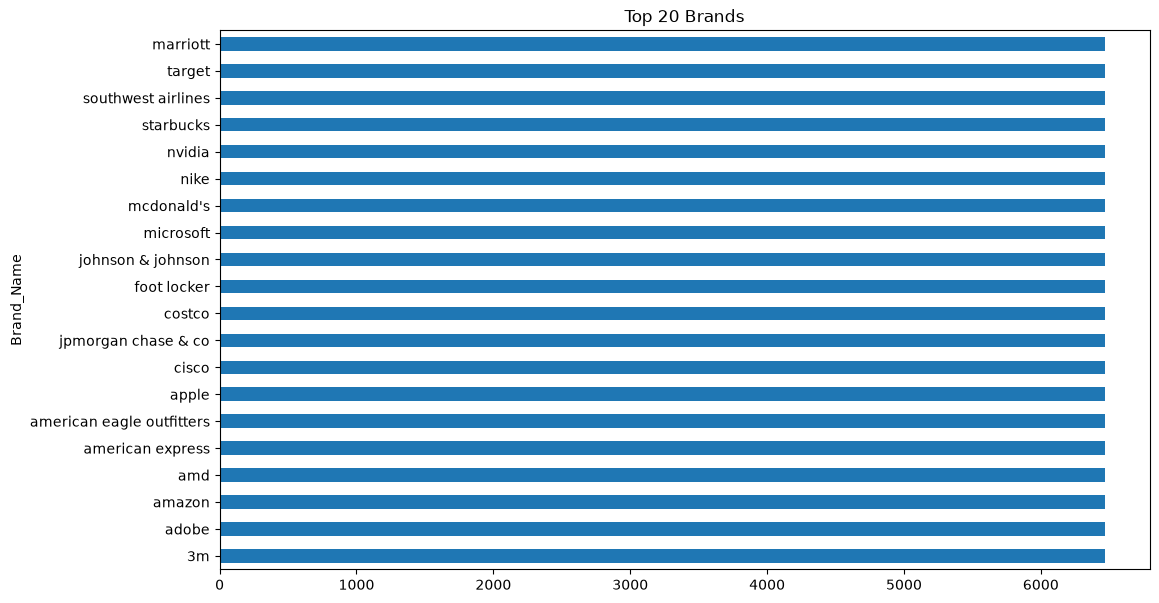

In [31]:
plt.figure(figsize=(12,7))

brand_counts.sort_values().plot(
    kind="barh"
)

plt.title("Top 20 Brands")

plt.show()

In [38]:
# Correlation Analysis

numerical_cols = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Dividends",
    "Stock Splits"
]

In [39]:
corr_matrix = df[numerical_cols].corr()

corr_matrix

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Open,1.000000,0.999918,0.999883,0.999811,-0.073025,0.019596,0.000402
High,0.999918,1.000000,0.999843,0.999895,-0.072692,0.019463,0.000438
Low,0.999883,0.999843,1.000000,0.999918,-0.073423,0.019718,-0.000678
Close,0.999811,0.999895,0.999918,1.000000,-0.073046,0.019593,-0.000579
Volume,-0.073025,-0.072692,-0.073423,-0.073046,1.000000,-0.009304,0.003784
Dividends,0.019596,0.019463,0.019718,0.019593,-0.009304,1.000000,-0.000365
Stock Splits,0.000402,0.000438,-0.000678,-0.000579,0.003784,-0.000365,1.000000


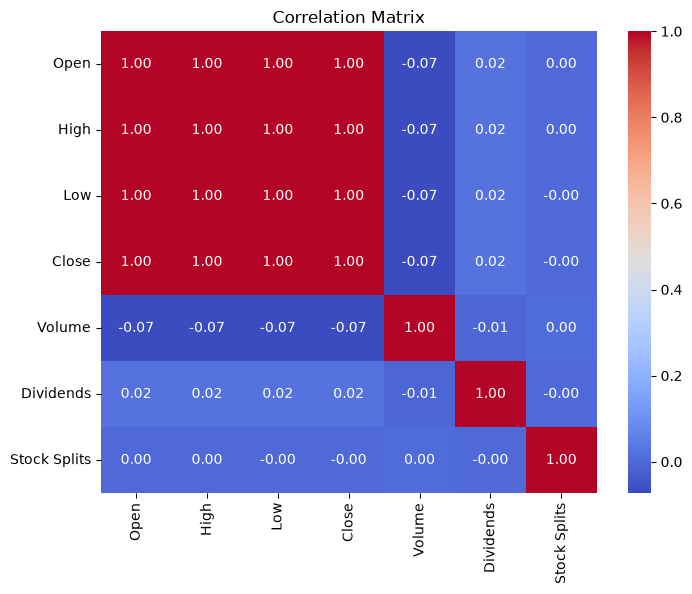

In [40]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

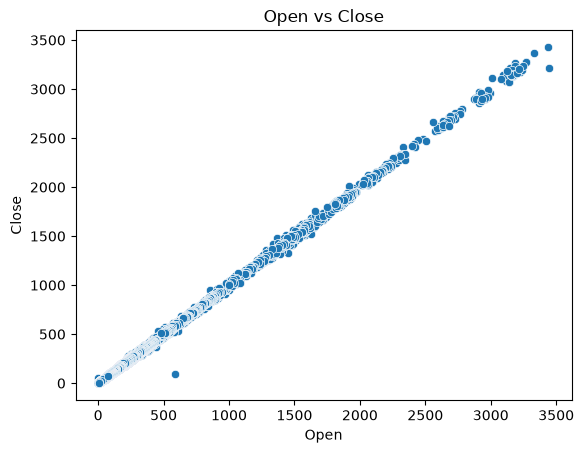

In [41]:
# Scatterplots

sns.scatterplot(
    data=df,
    x="Open",
    y="Close"
)

plt.title("Open vs Close")

plt.show()

In [42]:
# Industry vs Closing Price

top_industries = (
    df["Industry_Tag"]
    .value_counts()
    .head(10)
    .index
)

industry_df = df[
    df["Industry_Tag"].isin(top_industries)
]

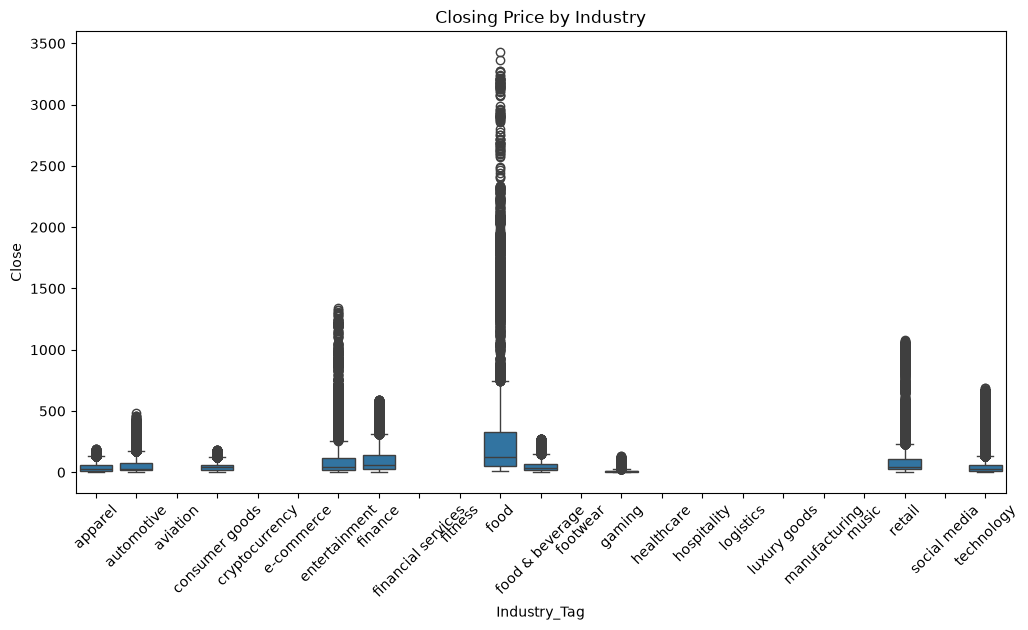

In [43]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=industry_df,
    x="Industry_Tag",
    y="Close"
)

plt.xticks(rotation=45)

plt.title(
    "Closing Price by Industry"
)

plt.show()

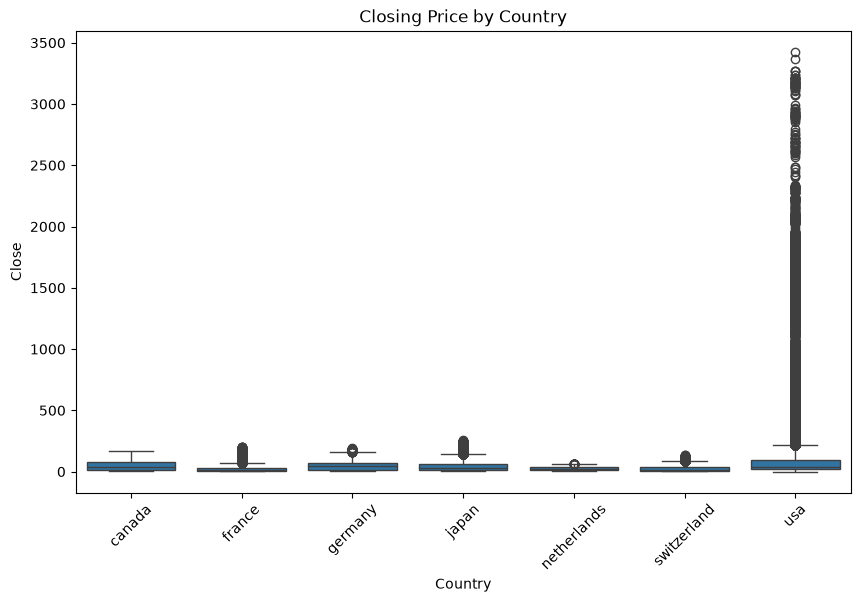

In [44]:
# Country vs Closing Price

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Country",
    y="Close"
)

plt.xticks(rotation=45)

plt.title(
    "Closing Price by Country"
)

plt.show()

# Data cleaning

# Parametric inference

## Confidence Interval

In [45]:
# variable of interest 

close_price = df["Close"]

>### Assumptions
- Random observations
- Continuous variable
- Large sample size (n > 30)

In [48]:
mean_close = close_price.mean()

ci_low, ci_high = stats.t.interval(
    confidence=0.95,
    df=len(close_price)-1,
    loc=mean_close,
    scale=stats.sem(close_price)
)

print(f"Mean Close Price: {mean_close:.2f}")
print(f"95% CI: ({ci_low:.2f}, {ci_high:.2f})")

Mean Close Price: 76.34
95% CI: (75.84, 76.84)


>> Interpretation Template

We are 95% confident that the true mean closing stock price lies between the lower and upper confidence limits.

### One-Sample t-Test

>> Hypotheses
>>>Null
H0 :μ=100

>>>Alternative
H1:μ=100

In [56]:
t_stat, p_value = stats.ttest_1samp(
    df["Close"],
    popmean=75
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 5.259288850355159
P-value: 1.4470915382943534e-07


In [54]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Reject H0


In [57]:
t_stat, p_value = stats.ttest_1samp(
    df["Close"],
    popmean=75.90
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.721736141720363
P-value: 0.0851183243194159


In [58]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Fail to Reject H0


### Independent Two-Sample t-Test

In [59]:
df["USA_Group"] = np.where(
    df["Country"] == "usa",
    "USA",
    "Non-USA"
)

>> Research Question

Is there a difference in average closing prices between USA and Non-USA companies?

>> Hypotheses
Null

H0:μUSA=μNon−USA
	​
Alternative
H1:μUSA=μNon−USA

#### Assumptions
- Normality

In [60]:
stats.shapiro(
    df.sample(5000)["Close"]
)

ShapiroResult(statistic=np.float64(0.42357758308423854), pvalue=np.float64(2.9639378134462506e-83))

- Equal Variance

In [61]:
usa = df[df["USA_Group"]=="USA"]["Close"]

non_usa = df[df["USA_Group"]=="Non-USA"]["Close"]

stats.levene(
    usa,
    non_usa
)

LeveneResult(statistic=np.float64(4624.120362798224), pvalue=np.float64(0.0))

In [62]:
t_stat, p_value = stats.ttest_ind(
    usa,
    non_usa,
    equal_var=False
)

print(t_stat)
print(p_value)

130.6069416637685
0.0


### One-Way ANOVA

In [63]:
top_industries = (
    df["Industry_Tag"]
    .value_counts()
    .head(5)
    .index
)

anova_df = df[
    df["Industry_Tag"].isin(top_industries)
]

####  Research Question

Do average closing stock prices differ across industries?

Hypotheses
Null
H0:μ1=μ2=μ3=⋯
Alternative

At least one industry mean differs.

#### Assumptions
Normality

In [64]:
for industry in top_industries:
    
    sample = anova_df[
        anova_df["Industry_Tag"] == industry
    ]["Close"]
    
    print(
        industry,
        stats.shapiro(
            sample.sample(
                min(500,len(sample))
            )
        )
    )

technology ShapiroResult(statistic=np.float64(0.6513695359337108), pvalue=np.float64(1.1332413814842193e-30))
retail ShapiroResult(statistic=np.float64(0.6099730842526052), pvalue=np.float64(4.863673692796248e-32))
automotive ShapiroResult(statistic=np.float64(0.7711635841345091), pvalue=np.float64(8.041660372064105e-26))
finance ShapiroResult(statistic=np.float64(0.7862986178334833), pvalue=np.float64(4.48877847233113e-25))
apparel ShapiroResult(statistic=np.float64(0.8212431038046019), pvalue=np.float64(3.5149925670279045e-23))


- Homogeneity of Variance

In [65]:
groups = [
    
    anova_df[
        anova_df["Industry_Tag"] == industry
    ]["Close"]
    
    for industry in top_industries
]

stats.levene(*groups)

LeveneResult(statistic=np.float64(1049.3105743383546), pvalue=np.float64(0.0))

In [66]:
f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 1806.3423853163763
P-value: 0.0


### Linear Regression

In [67]:
import statsmodels.api as sm

X = df["Open"]
y = df["Close"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 8.190e+08
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:16:42   Log-Likelihood:            -7.5448e+05
No. Observations:              310122   AIC:                         1.509e+06
Df Residuals:                  310120   BIC:                         1.509e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0297      0.006      5.284      0.0

# Nop parametric Models 

### 1. Bootstrap Confidence Interval

In [69]:
from scipy.stats import bootstrap
import numpy as np

close_values = df["Close"].dropna().values

bootstrap_result = bootstrap(
    data=(close_values,),
    statistic=np.mean,
    confidence_level=0.95,
    n_resamples=5000,
    method="percentile",
    batch=200,
    random_state=42
)

print("Bootstrap 95% CI:")
print("Lower:", bootstrap_result.confidence_interval.low)
print("Upper:", bootstrap_result.confidence_interval.high)

Bootstrap 95% CI:
Lower: 75.84973329756362
Upper: 76.84824910850301


### Mann-Whitney U Test

\[
H_0:
\text{The distributions of closing stock prices are identical for USA and Non-USA companies}
\]

\[
H_1:
\text{The distributions of closing stock prices differ between USA and Non-USA companies}
\]

In [70]:
from scipy.stats import mannwhitneyu

u_stat, p_value = mannwhitneyu(
    usa,
    non_usa,
    alternative="two-sided"
)

print("U-statistic:", u_stat)
print("P-value:", p_value)

U-statistic: 10058752367.0
P-value: 0.0


In [71]:
print("USA Median:", usa.median())
print("Non-USA Median:", non_usa.median())

print("USA Sample Size:", len(usa))
print("Non-USA Sample Size:", len(non_usa))

USA Median: 39.41267204284668
Non-USA Median: 25.03789520263672
USA Sample Size: 243606
Non-USA Sample Size: 66516


### Kruskal-Wallis Test


In [72]:
from scipy.stats import kruskal

h_stat, p_value = kruskal(*groups)

print("H-statistic:", h_stat)
print("P-value:", p_value)

H-statistic: 12507.080508132503
P-value: 0.0


In [73]:
anova_df.groupby(
    "Industry_Tag"
)["Close"].median().sort_values(
    ascending=False
)

Industry_Tag
finance      56.223665
retail       39.175827
automotive   30.840933
technology   24.540001
apparel      23.091404
Name: Close, dtype: float64